In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import requests

PART - A

In [3]:
df = pd.read_csv("/content/patient_health_records_500.csv")

In [4]:
df

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P001,NaN,Female,South,NaN,122.328403,NaN,114.807324,0
1,P002,69.0,Male,South,22.914993,146.717327,282.460193,106.294428,1
2,P003,NaN,NaN,NaN,NaN,82.981623,NaN,NaN,1
3,P004,32.0,Male,South,29.010172,183.755057,176.839323,74.686606,1
4,P005,60.0,Male,South,25.262366,107.577325,159.346380,66.403797,0
...,...,...,...,...,...,...,...,...,...
495,P496,NaN,NaN,NaN,NaN,116.008479,NaN,NaN,1
496,P497,41.0,Female,West,24.056182,145.350025,253.007037,116.713350,1
497,P498,NaN,NaN,NaN,NaN,178.263647,NaN,NaN,1
498,P499,49.0,Male,South,27.696713,119.089175,271.919990,144.914922,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      500 non-null    object 
 1   age             450 non-null    float64
 2   gender          460 non-null    object 
 3   region          465 non-null    object 
 4   bmi             440 non-null    float64
 5   blood_pressure  500 non-null    float64
 6   cholesterol     450 non-null    float64
 7   glucose         461 non-null    float64
 8   disease_risk    500 non-null    int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB


In [6]:
df.isnull().sum()

,0
patient_id,0
age,50
gender,40
region,35
bmi,60
blood_pressure,0
cholesterol,50
glucose,39
disease_risk,0


In [7]:
(df.isnull().sum()/len(df))*100

,0
patient_id,0.0
age,10.0
gender,8.0
region,7.0
bmi,12.0
blood_pressure,0.0
cholesterol,10.0
glucose,7.8
disease_risk,0.0


In [9]:
numeric_col = df.select_dtypes(include=np.number)

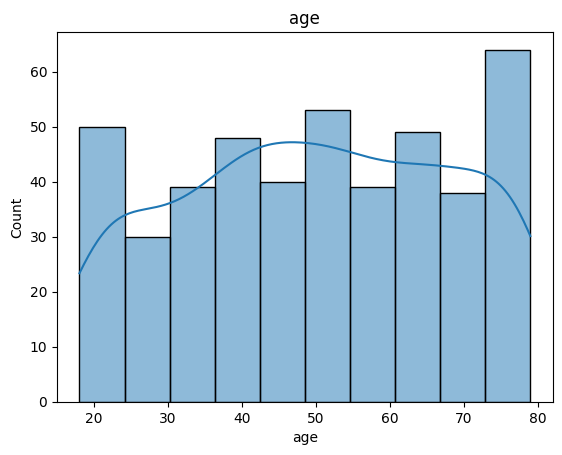

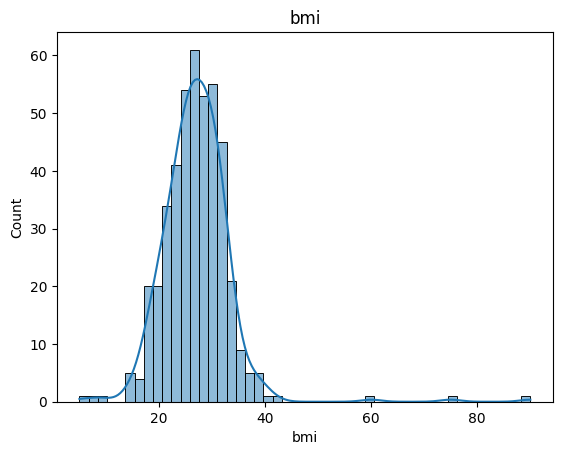

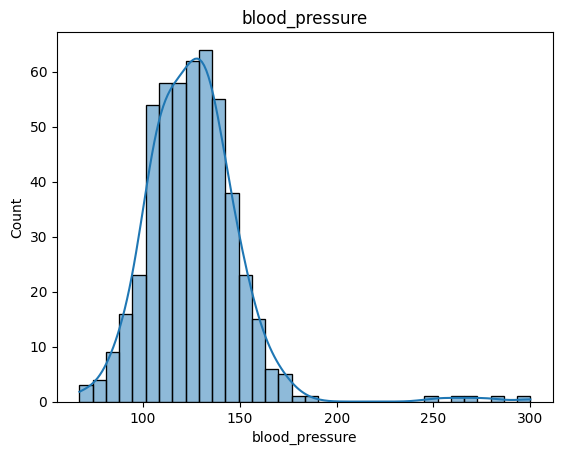

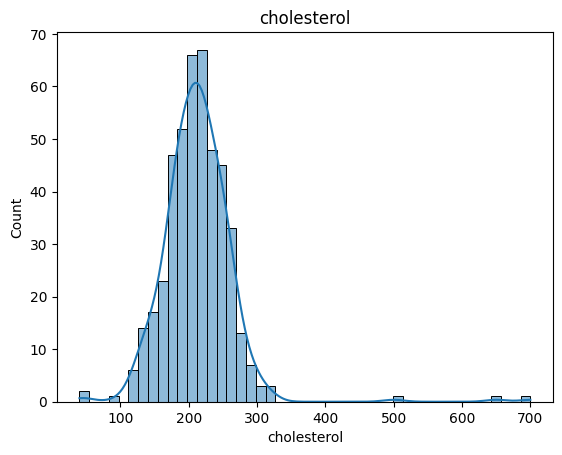

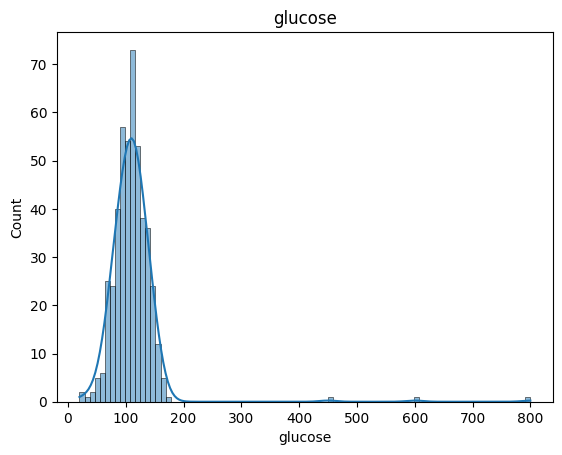

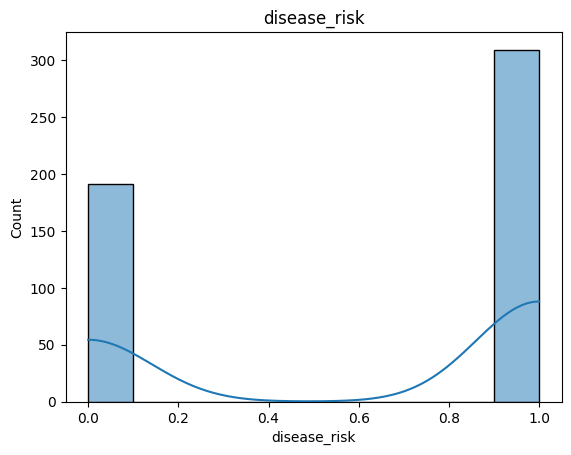

In [13]:
for i in numeric_col:
    sns.histplot(df[i],kde=True)
    plt.title(i)
    plt.show()

In [17]:
category_cols = df.select_dtypes(exclude=object)

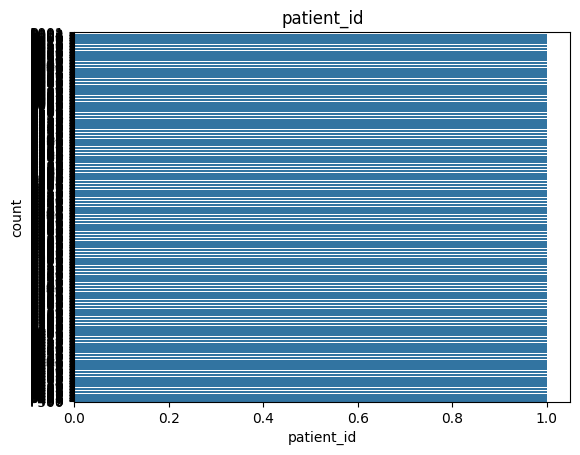

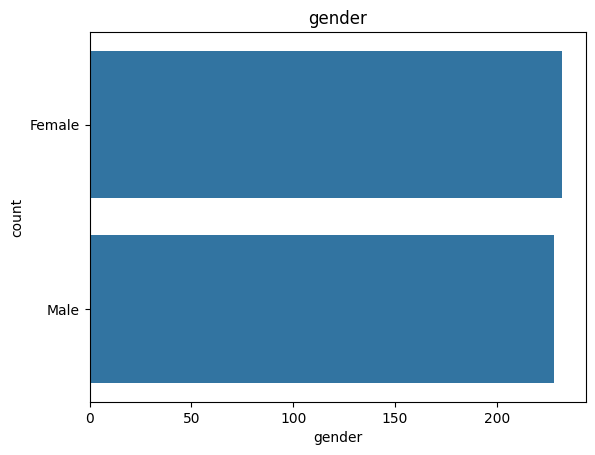

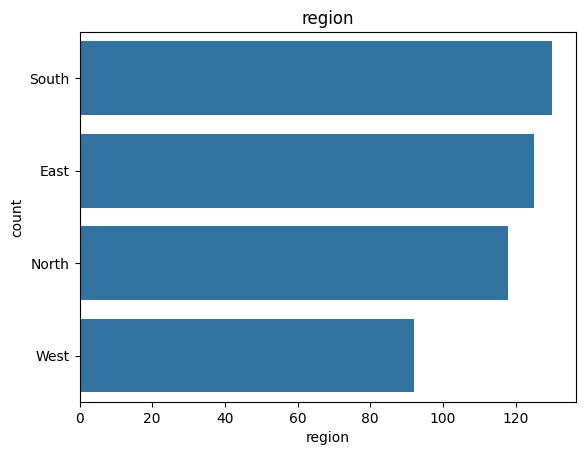

In [18]:
for j in category_cols:
    sns.countplot(df[j])
    plt.title(j)
    plt.xlabel(j)
    plt.ylabel('count')

    plt.show()

In [20]:
df.drop('patient_id', axis=1, inplace=True)

In [21]:
from sklearn.impute import SimpleImputer

In [22]:
median_imputer = SimpleImputer(strategy='median')

df_median = df.copy()

df_median[['bmi']] = median_imputer.fit_transform(df_median[['bmi']])

print(df_median['bmi'].isnull().sum())

0


In [23]:
cat_imputer = SimpleImputer(strategy='most_frequent')

df_region = df.copy()

df_region[['region']] = cat_imputer.fit_transform(df_region[['region']])

print(df_region['region'].isnull().sum())

0


In [24]:
gender_imputer = SimpleImputer(strategy='most_frequent')

df_gender = df.copy()

df_gender[['gender']] = gender_imputer.fit_transform(df_gender[['gender']])

print(df_gender['gender'].isnull().sum())

0


In [25]:
df_random = df.copy()

df_random['age_missing'] = np.where(
    df_random['age'].isnull(),1,0
)

In [26]:
random_sample = df_random['age'].dropna()

df_random.loc[
    df_random['age'].isnull(),
    'age'
] = np.random.choice(
    random_sample,
    df_random['age'].isnull().sum()
)

print(df_random['age'].isnull().sum())

0


In [27]:
from sklearn.impute import KNNImputer

knn_df = df.copy()

num_cols = [
    'age',
    'bmi',
    'blood_pressure',
    'cholesterol',
    'glucose'
]

knn = KNNImputer(n_neighbors=5)

knn_df[num_cols] = knn.fit_transform(
    knn_df[num_cols]
)

print(knn_df[num_cols].isnull().sum())

age               0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
dtype: int64


In [28]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice_df = df.copy()

mice = IterativeImputer(random_state=42)

mice_df[num_cols] = mice.fit_transform(
    mice_df[num_cols]
)

print(mice_df[num_cols].isnull().sum())

age               0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
dtype: int64


PART - B

In [29]:
from scipy.stats import zscore

z_df = mice_df.copy()

z_scores = np.abs(
    zscore(z_df[['cholesterol','glucose']])
)

outliers = (z_scores > 3)

print(np.sum(outliers))

8


In [30]:
Q1 = mice_df['bmi'].quantile(0.25)
Q3 = mice_df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

iqr_outliers = mice_df[
    (mice_df['bmi'] < lower) |
    (mice_df['bmi'] > upper)
]

print(iqr_outliers.shape)

(18, 8)


In [31]:
p1 = mice_df['glucose'].quantile(0.01)
p99 = mice_df['glucose'].quantile(0.99)

percentile_df = mice_df.copy()

percentile_df['glucose'] = np.clip(
    percentile_df['glucose'],
    p1,
    p99
)

In [32]:
from scipy.stats.mstats import winsorize

winsor_df = mice_df.copy()

winsor_df['cholesterol'] = winsorize(
    winsor_df['cholesterol'],
    limits=[0.01,0.01]
)

In [33]:
print("Original Shape")
print(df.shape)

print("After Cleaning")
print(winsor_df.shape)

print("\nBefore")
print(df.describe())

print("\nAfter")
print(winsor_df.describe())

Original Shape
(500, 8)
After Cleaning
(500, 8)

Before
              age         bmi  blood_pressure  cholesterol     glucose  \
count  450.000000  440.000000      500.000000   450.000000  461.000000   
mean    49.948889   26.997418      125.950147   212.856584  111.505735   
std     18.233808    6.574284       24.673412    52.890588   49.472580   
min     18.000000    5.000000       67.234576    40.000000   20.000000   
25%     35.000000   23.470361      110.394473   184.030922   91.913430   
50%     50.000000   26.850292      125.459984   211.258306  110.011137   
75%     65.750000   30.165116      137.846652   239.860652  126.029667   
max     79.000000   90.000000      300.000000   700.000000  800.000000   

       disease_risk  
count    500.000000  
mean       0.618000  
std        0.486363  
min        0.000000  
25%        0.000000  
50%        1.000000  
75%        1.000000  
max        1.000000  

After
              age         bmi  blood_pressure  cholesterol     glucose  

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [34]:
winsor_df.to_csv("final_clean_dataset.csv",index=False)

print("Dataset Saved")

Dataset Saved


In [35]:
winsor_df

,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,49.948507,Female,South,26.999193,122.328403,212.857730,114.807324,0
1,69.000000,Male,South,22.914993,146.717327,282.460193,106.294428,1
2,49.943523,NaN,NaN,27.000969,82.981623,212.874586,111.514200,1
3,32.000000,Male,South,29.010172,183.755057,176.839323,74.686606,1
4,60.000000,Male,South,25.262366,107.577325,159.346380,66.403797,0
...,...,...,...,...,...,...,...,...
495,49.947635,NaN,NaN,26.998506,116.008479,212.860770,111.507715,1
496,41.000000,Female,West,24.056182,145.350025,253.007037,116.713350,1
497,49.955386,NaN,NaN,26.993861,178.263647,212.834728,111.495489,1
498,49.000000,Male,South,27.696713,119.089175,271.919990,144.914922,1


Which imputation strategy was most effective?

MICE Algorithm was most effective because it uses relationships among multiple variables and provides more accurate estimates compared to mean or mode imputation.

Which outlier handling method preserved data quality best?

Winsorization preserved data quality best because it retained all observations while reducing the impact of extreme values

How data cleaning improved usability?

Removed missing values

Reduced impact of outliers

Improved consistency

Enhanced model performance

Made dataset machine learning ready